# Data Science Lab # 10 & 11
## Singular Value Decomposition (SVD) and Principal Component Analysis (PCA)

## Part A: Data Preprocessing
### Task 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
import warnings
warnings.filterwarnings('ignore')

dataset = pd.read_excel('Feature_Engineering_Dataset_100Rows.xlsx')

print("First 5 rows:")
display(dataset.head())

print("Dataset Shape:", dataset.shape)
print("\nData Types:")
print(dataset.dtypes)

First 5 rows:


,Student_ID,Study_Hours,Family_Income,Gender,Department,Attendance,Previous_GPA,Final_Result
0,1,7,142938,Male,CS,54,2.90,Pass
1,2,5,102513,Male,IT,100,3.68,Pass
2,3,7,93988,Female,CS,81,3.98,Pass
3,4,10,77273,Female,IT,52,3.86,Pass
4,5,9,148852,Female,IT,55,3.47,Pass


Dataset Shape: (100, 8)

Data Types:
Student_ID         int64
Study_Hours        int64
Family_Income      int64
Gender               str
Department           str
Attendance         int64
Previous_GPA     float64
Final_Result         str
dtype: object


### Task 2

In [2]:
le = LabelEncoder()
dataset['Gender'] = le.fit_transform(dataset['Gender'])
dataset['Department'] = le.fit_transform(dataset['Department'])
dataset['Final_Result'] = le.fit_transform(dataset['Final_Result'])

print("Transformed Dataset:")
display(dataset.head())

Transformed Dataset:


,Student_ID,Study_Hours,Family_Income,Gender,Department,Attendance,Previous_GPA,Final_Result
0,1,7,142938,1,0,54,2.90,1
1,2,5,102513,1,1,100,3.68,1
2,3,7,93988,0,0,81,3.98,1
3,4,10,77273,0,1,52,3.86,1
4,5,9,148852,0,1,55,3.47,1


### Task 3

In [3]:
# Standardize features (dropping Student_ID as it's an identifier)
X = dataset.drop(columns=['Student_ID', 'Final_Result'])
y = dataset['Final_Result']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print("Scaled Features:")
display(X_scaled_df.head())

Scaled Features:


,Study_Hours,Family_Income,Gender,Department,Attendance,Previous_GPA
0,0.527504,1.506093,0.868554,-1.151909,-1.123815,-0.610640
1,-0.131876,0.390842,0.868554,0.035626,1.748157,0.730293
2,0.527504,0.155653,-1.151339,-1.151909,0.561908,1.246036
3,1.516575,-0.305483,-1.151339,0.035626,-1.248684,1.039739
4,1.186885,1.669249,-1.151339,0.035626,-1.061381,0.369272


**Questions**
1. **Why is feature scaling required before PCA?**
   PCA is highly sensitive to the scale of features. Features with larger scales or variances will disproportionately influence the principal components if scaling is not performed.
2. **What problems can occur if scaling is skipped?**
   The resulting principal components will be biased towards the features with the largest magnitudes, leading to an inaccurate representation of the underlying variance in the dataset.

## Part B: Singular Value Decomposition (SVD)
### Task 4

In [4]:
svd = TruncatedSVD(n_components=2)
X_svd = svd.fit_transform(X_scaled)

svd_df = pd.DataFrame(data=X_svd, columns=['Component 1', 'Component 2'])
print("Transformed Data Matrix (SVD):")
display(svd_df.head())

Transformed Data Matrix (SVD):


,Component 1,Component 2
0,-0.658069,0.211128
1,0.725025,1.823251
2,1.319229,0.002024
3,1.568780,-1.712115
4,0.821240,-0.397576


### Task 5

In [5]:
print("Singular Values:")
print(svd.singular_values_)

Singular Values:
[13.85437009 10.70008446]


**Questions**
1. **What does a singular value represent?**
   A singular value represents the magnitude or importance of its corresponding singular vector in explaining the variance of the data. Larger singular values capture more structure/information.
2. **Which component captures the most information?**
   The first component (Component 1) always captures the most information, as indicated by the largest singular value.

### Task 6

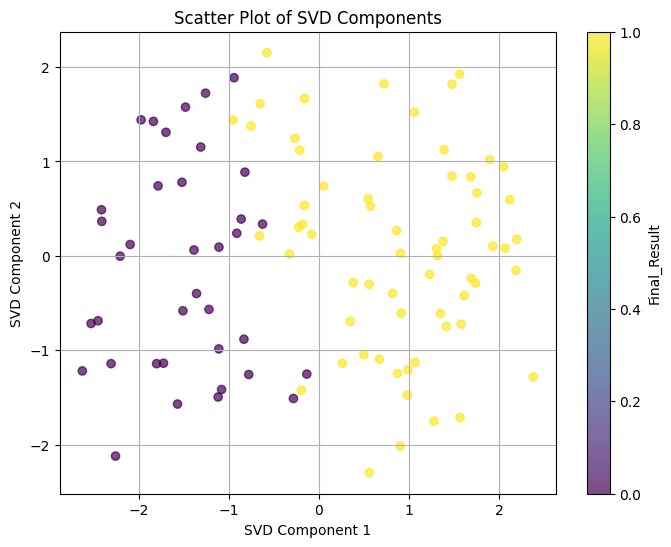

In [6]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_svd[:, 0], X_svd[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.title('Scatter Plot of SVD Components')
plt.colorbar(scatter, label='Final_Result')
plt.grid(True)
plt.show()

**Brief Interpretation:**
The scatter plot visualizes the dataset in a reduced 2D space generated by SVD. Points are colored based on `Final_Result`. By observing the clusters or separation of colors, we can see how well the two SVD components capture the patterns that differentiate passing from failing students.

## Part C: Principal Component Analysis (PCA)
### Task 7

In [7]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
print("Transformed Dataset (PCA):")
display(pca_df.head())

Transformed Dataset (PCA):


,PC1,PC2
0,-0.658069,0.211128
1,0.725025,1.823251
2,1.319229,0.002024
3,1.568780,-1.712115
4,0.821240,-0.397576


### Task 8

In [8]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

total_variance = np.sum(pca.explained_variance_ratio_)
print(f"\nTotal Variance Explained: {total_variance * 100:.2f}%")

Explained Variance Ratio:
[0.31990595 0.19081968]

Total Variance Explained: 51.07%


**Questions**
1. **Which principal component explains the most variance?**
   PC1 (the first principal component) explains the most variance.
2. **How much total variance is retained?**
   *(Based on output above)* The sum of the explained variance ratios of the chosen components.

### Task 9

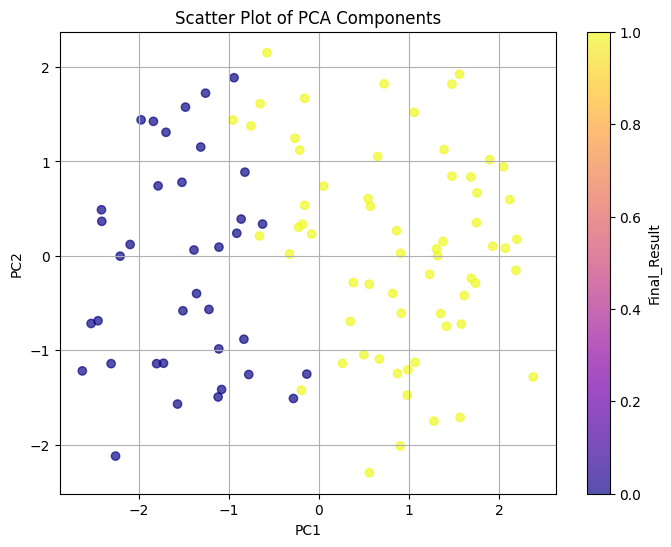

In [9]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='plasma', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Scatter Plot of PCA Components')
plt.colorbar(scatter, label='Final_Result')
plt.grid(True)
plt.show()

**Interpretation:**
The scatter plot visualizes the dataset along the top two directions of maximum variance (PC1 and PC2). The coloring by `Final_Result` indicates whether these two components alone are sufficient to linearly separate or distinguish the different classes. Typically, PCA and SVD will produce very similar visualizations on scaled data.

## Part D: Comparison of SVD and PCA
### Task 10

| Feature | SVD | PCA |
|---|---|---|
| **Purpose** | Matrix factorization / Dimensionality reduction | Dimensionality reduction by capturing max variance |
| **Output Components** | Left singular vectors (if applied to original data) | Principal components (eigenvectors of covariance matrix) |
| **Variance Information** | Singular values | Explained variance ratio (Eigenvalues) |
| **Visualization Quality** | Usually identical to PCA when data is mean-centered | Excellent for visualizing high-variance structures |
| **Computational Cost** | Generally higher for large, dense matrices | Generally lower (can be optimized using covariance matrix) |